**Autonomous Navigation - YOLO**

*prageethM*

![](https://user-images.githubusercontent.com/56669525/67030475-7091fb80-f14a-11e9-8eeb-e71a8f3b4ee2.jpg)

In [1]:
import os
import pandas as pd
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [2]:
dataset_path ="/kaggle/input/udacity-self-driving-car-dataset/data"
csv_files = []
txt_files = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))
        if file.endswith(".txt"):
            txt_files.append(os.path.join(root, file))

print("CSV Files Found:", csv_files)
print("TXT Files Found:", txt_files)

CSV Files Found: ['/kaggle/input/udacity-self-driving-car-dataset/data/export/_annotations.csv']
TXT Files Found: []


In [3]:
csv_source_path = "/kaggle/input/udacity-self-driving-car-dataset/data/export/_annotations.csv"
txt_source_path = "/kaggle/input/udacity-self-driving-car-dataset/README.roboflow.txt"
csv_download_path = "/kaggle/working/"
txt_download_path = "/kaggle/working/"
try:
    shutil.copy(csv_source_path, csv_download_path)
    print(f"CSV file copied to: {csv_download_path}")
except FileNotFoundError:
    print("CSV file not found.")

try:
    shutil.copy(txt_source_path, txt_download_path)
    print(f"TXT file copied to: {txt_download_path}")
except FileNotFoundError:
    print("TXT file not found.")

CSV file copied to: /kaggle/working/
TXT file copied to: /kaggle/working/


In [4]:
csv_path = "/kaggle/working/_annotations.csv"
df = pd.read_csv(csv_path)
print("CSV File Structure:")
print(df.head())

CSV File Structure:
                                            filename  width  height  \
0  1478900859981702684_jpg.rf.6830635c7d919747563...    512     512   
1  1478900859981702684_jpg.rf.6830635c7d919747563...    512     512   
2  1478900859981702684_jpg.rf.6830635c7d919747563...    512     512   
3  1478900859981702684_jpg.rf.6830635c7d919747563...    512     512   
4  1478900859981702684_jpg.rf.6830635c7d919747563...    512     512   

        class  xmin  ymin  xmax  ymax  
0         car   291   247   370   331  
1  pedestrian   270   235   293   321  
2         car     0   266    13   327  
3         car    25   258   106   304  
4         car   111   259   135   289  


In [5]:
print(df.columns)

Index(['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax'], dtype='object')


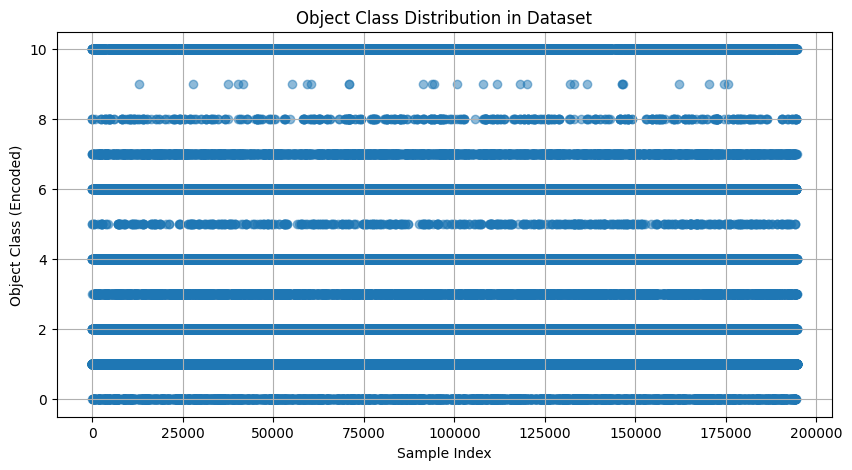

In [6]:
plt.figure(figsize=(10, 5))
plt.scatter(range(len(df)), df["class"].astype("category").cat.codes, alpha = 0.5)
plt.xlabel("Sample Index")
plt.ylabel("Object Class (Encoded)")
plt.title("Object Class Distribution in Dataset")
plt.grid(True)
plt.show()

In [7]:
image_folder = "/kaggle/input/udacity-self-driving-car-dataset/data/export"

def detect_edges(image_path):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0) 
    edges = cv2.Canny(blurred, 50, 150)  
    return edges

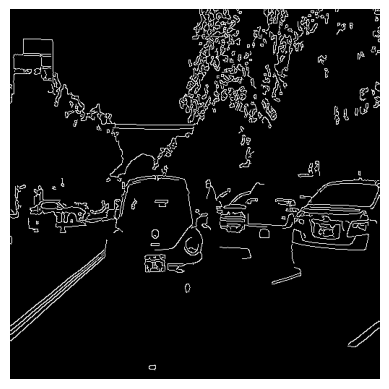

In [8]:
sample_image_path = os.path.join(image_folder, df.iloc[0]["filename"])
edges = detect_edges(sample_image_path)

plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.show()

In [9]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 922.2/922.2 kB 17.5 MB/s eta 0:00:0000:01


In [10]:
yolo_labels_dir = "/kaggle/working/yolo_labels"
os.makedirs(yolo_labels_dir, exist_ok=True)
for index, row in df.iterrows():
    filename = row["filename"].replace(".jpg", ".txt")
    label_path = os.path.join(yolo_labels_dir, filename)

    width, height = row["width"], row["height"]
    x_center = (row["xmin"] + row["xmax"]) / 2 / width
    y_center = (row["ymin"] + row["ymax"]) / 2 / height
    bbox_width = (row["xmax"] - row["xmin"]) / width
    bbox_height = (row["ymax"] - row["ymin"]) / height

    with open(label_path, "w") as f:
        f.write(f"0 {x_center} {y_center} {bbox_width} {bbox_height}\n")

In [11]:
images_dir = "/kaggle/working/yolo_images"
os.makedirs(images_dir, exist_ok=True)
image_folder = "/kaggle/input/udacity-self-driving-car-dataset/data/export"

for index, row in df.iterrows():
    img_path = os.path.join(image_folder, row["filename"])
    if os.path.exists(img_path):
        shutil.copy(img_path, images_dir)

In [12]:
dataset_path = "/kaggle/working/yolo_dataset"
images_path = os.path.join(dataset_path, "images")
labels_path = os.path.join(dataset_path, "labels")
os.makedirs(images_path, exist_ok=True)
os.makedirs(labels_path, exist_ok=True)

print("Dataset folders created successfully.")

Dataset folders created successfully.


In [13]:
csv_path = "/kaggle/working/_annotations.csv"
df = pd.read_csv(csv_path)
source_image_folder = "/kaggle/input/udacity-self-driving-car-dataset/data/export"
for index, row in df.iterrows():
    img_filename = row["filename"]
    txt_filename = img_filename.replace(".jpg", ".txt")
    img_src_path = os.path.join(source_image_folder, img_filename)
    img_dest_path = os.path.join(images_path, img_filename)
    if os.path.exists(img_src_path):
        shutil.copy(img_src_path, img_dest_path)

    label_dest_path = os.path.join(labels_path, txt_filename)
    width, height = row["width"], row["height"]
    x_center = (row["xmin"] + row["xmax"]) / 2 / width
    y_center = (row["ymin"] + row["ymax"]) / 2 / height
    bbox_width = (row["xmax"] - row["xmin"]) / width
    bbox_height = (row["ymax"] - row["ymin"]) / height

    with open(label_dest_path, "w") as f:
        f.write(f"0 {x_center} {y_center} {bbox_width} {bbox_height}\n")
print("Images and labels moved successfully.")

Images and labels moved successfully.


In [14]:
yaml_path = "/kaggle/working/yolo_dataset/data.yaml"

with open(yaml_path, "w") as f:
    f.write(f"""
    path: /kaggle/working/yolo_dataset
    train: images
    val: images
    nc: 1
    names: ['obstacle']
    """)
print("Dataset configuration file created successfully.")

Dataset configuration file created successfully.


In [15]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
model.train(data = "/kaggle/working/yolo_dataset/data.yaml", epochs = 5, imgsz = 512, batch = 8, name = "yolo_v8_model")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 78.4MB/s]


Ultralytics 8.3.85 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/kaggle/working/yolo_dataset/data.yaml, epochs=5, time=None, patience=100, batch=8, imgsz=512, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=yolo_v8_model, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_con

100%|██████████| 755k/755k [00:00<00:00, 17.6MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1644/1644 [02:08<00:00, 12.84it/s]


                   all      26300      26300      0.659      0.606      0.641       0.38


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.1ms preprocess, 1.3ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/detect/yolo_v8_model


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b7000780520>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [16]:
results_path = "/kaggle/working/runs/detect/yolo_v8_model"
os.listdir(results_path)

['weights',
 'val_batch1_pred.jpg',
 'labels_correlogram.jpg',
 'labels.jpg',
 'train_batch1.jpg',
 'results.png',
 'val_batch2_labels.jpg',
 'confusion_matrix_normalized.png',
 'val_batch1_labels.jpg',
 'val_batch0_pred.jpg',
 'R_curve.png',
 'events.out.tfevents.1741455867.6cd5553c5587.31.0',
 'val_batch2_pred.jpg',
 'args.yaml',
 'train_batch2.jpg',
 'P_curve.png',
 'PR_curve.png',
 'train_batch0.jpg',
 'confusion_matrix.png',
 'F1_curve.png',
 'results.csv',
 'val_batch0_labels.jpg']

In [17]:
results_csv = os.path.join(results_path, "results.csv")
df_results = pd.read_csv(results_csv)
print(df_results.head())

   epoch      time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1   424.203         1.73733         2.27427         1.28781   
1      2   835.029         1.70722         1.78509         1.29986   
2      3  1240.160         1.65339         1.64805         1.26459   
3      4  1642.310         1.58422         1.51174         1.23188   
4      5  2044.560         1.49633         1.36960         1.18846   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.34233            0.40042           0.30674   
1               0.51577            0.46113           0.44771   
2               0.55060            0.52860           0.51236   
3               0.60303            0.57332           0.58552   
4               0.65815            0.60650           0.64120   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.16786       1.87488       2.09891       1.33479  0.000666   
1              0.24672       1.77922  

In [20]:
print("Available Columns:", df_results.columns)

Available Columns: Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


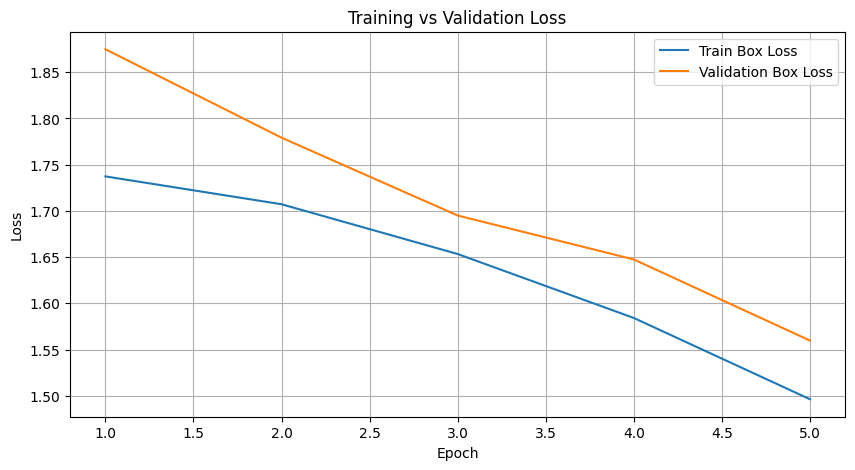

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(df_results["epoch"], df_results["train/box_loss"], label="Train Box Loss")
plt.plot(df_results["epoch"], df_results["val/box_loss"], label="Validation Box Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

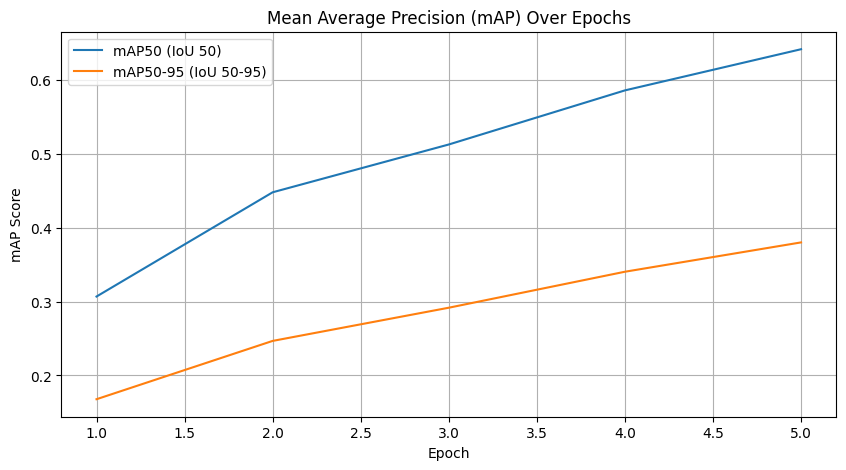

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(df_results["epoch"], df_results["metrics/mAP50(B)"], label="mAP50 (IoU 50)")
plt.plot(df_results["epoch"], df_results["metrics/mAP50-95(B)"], label="mAP50-95 (IoU 50-95)")
plt.xlabel("Epoch")
plt.ylabel("mAP Score")
plt.title("Mean Average Precision (mAP) Over Epochs")
plt.legend()
plt.grid()
plt.show()

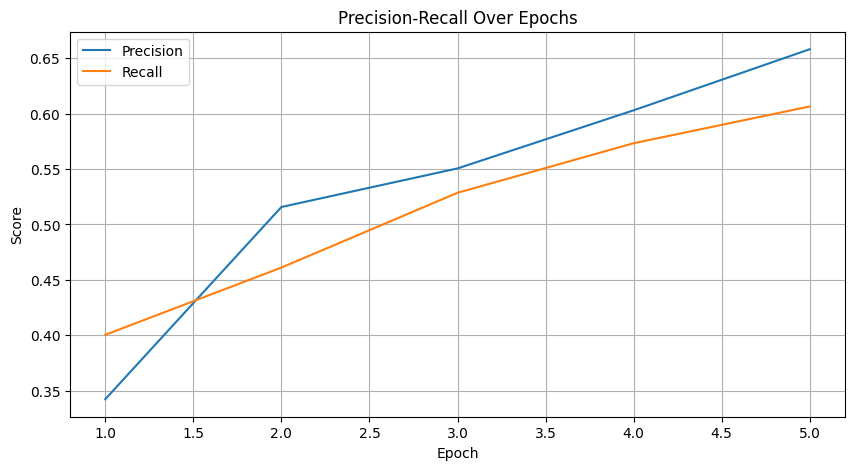

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(df_results["epoch"], df_results["metrics/precision(B)"], label="Precision")
plt.plot(df_results["epoch"], df_results["metrics/recall(B)"], label="Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Precision-Recall Over Epochs")
plt.legend()
plt.grid()
plt.show()

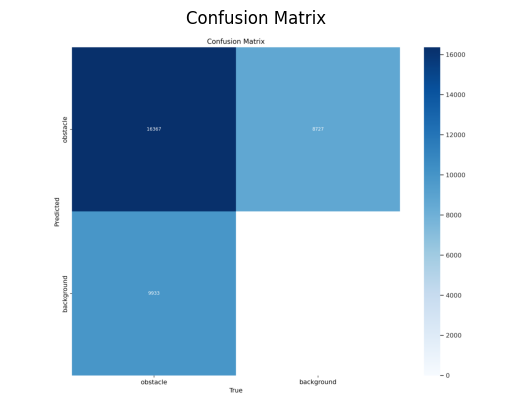

In [25]:
conf_matrix_path = "/kaggle/working/runs/detect/yolo_v8_model/confusion_matrix.png"
conf_matrix = cv2.imread(conf_matrix_path)
plt.imshow(cv2.cvtColor(conf_matrix, cv2.COLOR_BGR2RGB))
plt.title("Confusion Matrix")
plt.axis("off")
plt.show()


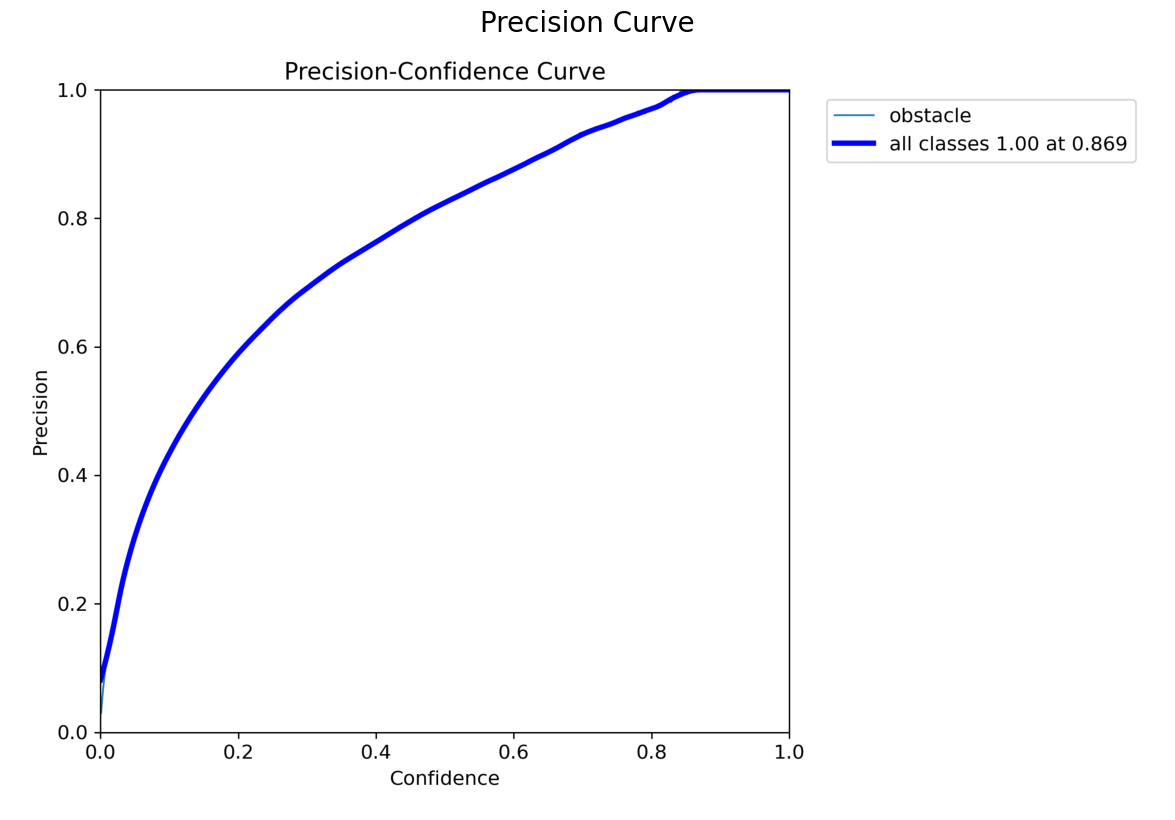

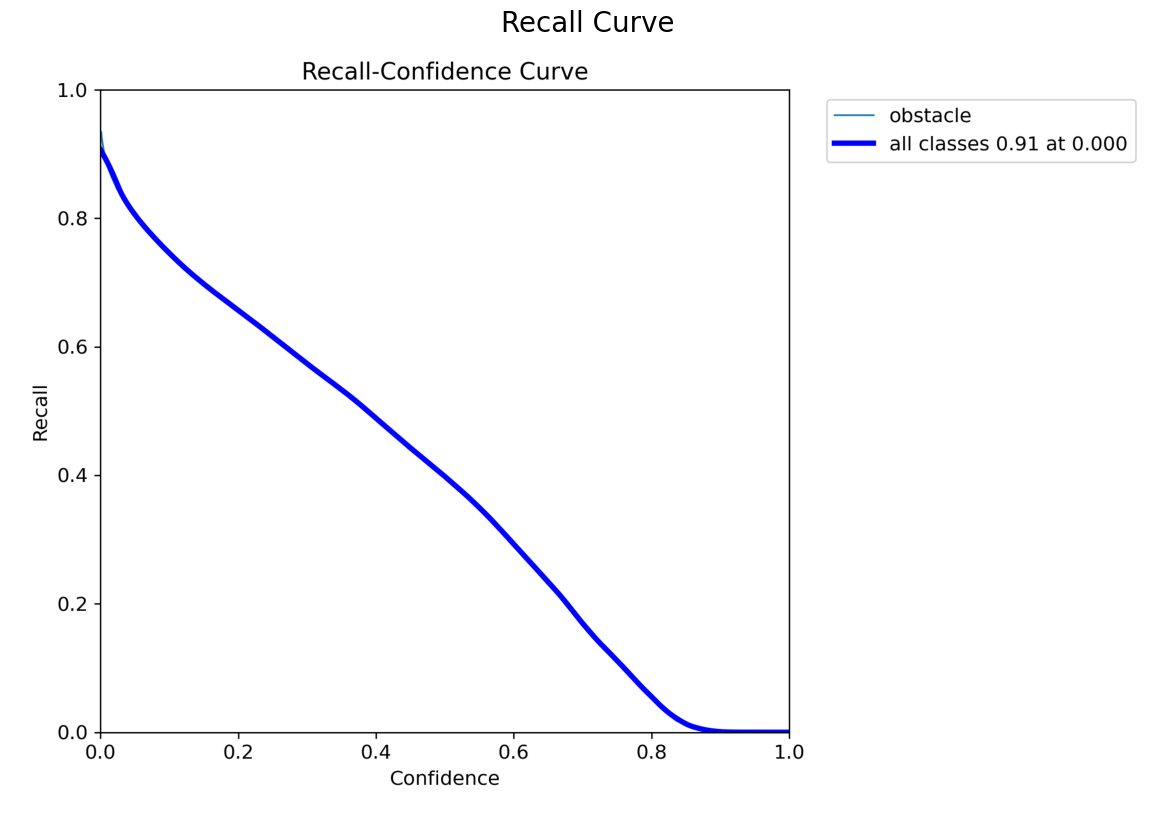

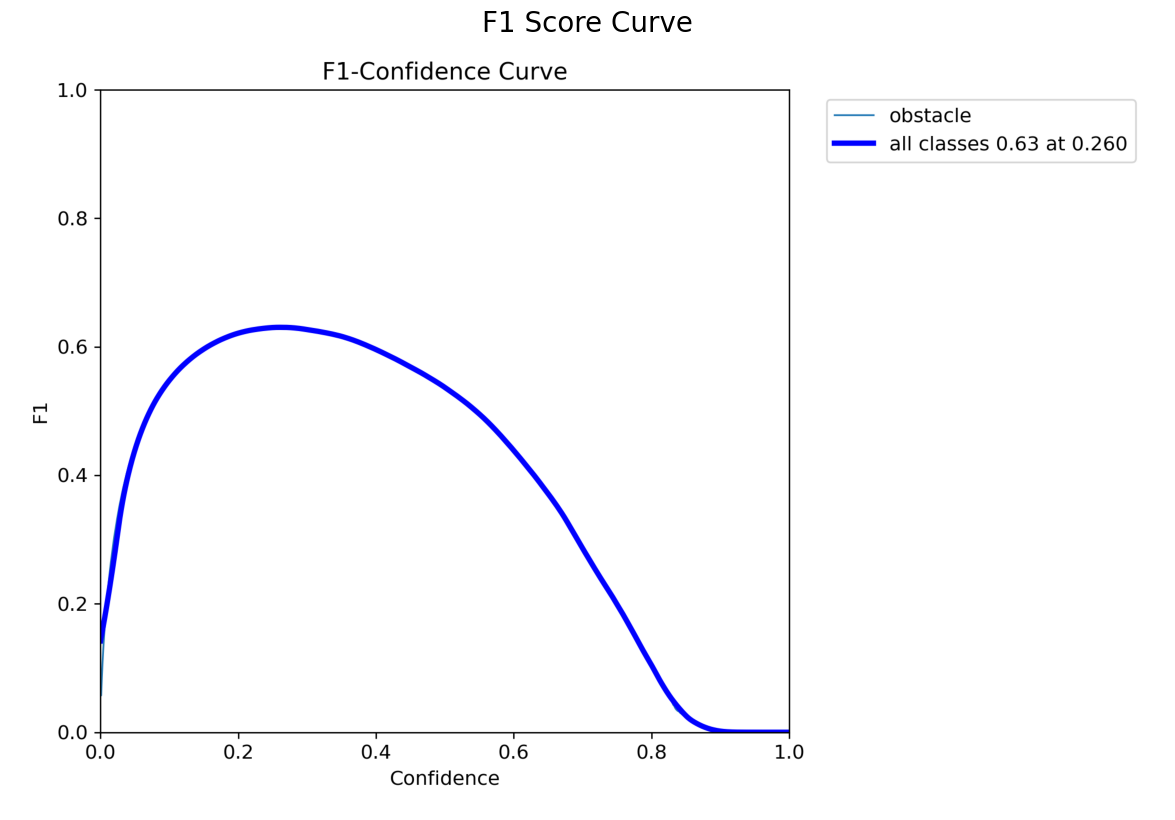

In [35]:
precision_curve = cv2.imread("/kaggle/working/runs/detect/yolo_v8_model/P_curve.png")
recall_curve = cv2.imread("/kaggle/working/runs/detect/yolo_v8_model/R_curve.png")
f1_curve = cv2.imread("/kaggle/working/runs/detect/yolo_v8_model/F1_curve.png")

def show_large_image(image, title):
    plt.figure(figsize=(15, 10))  # Bigger image
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title, fontsize=20)
    plt.axis("off")
    plt.show()
show_large_image(precision_curve, "Precision Curve")
show_large_image(recall_curve, "Recall Curve")
show_large_image(f1_curve, "F1 Score Curve")